# Importing Packages #

In [1]:
import pandas as pd
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import random
import speech_recognition as sr
from keras.models import Sequential, load_model
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Activation, BatchNormalization, Flatten, SimpleRNN, LSTM
from keras.optimizers import Adam
from keras.utils import np_utils, to_categorical
from keras import regularizers
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Loading Dataset #

The Ryerson Audio-Visual Database of Emotional Speech and Sound (RAVDESS) dataset was a collection of speech and song, audio and video. For this task, we are only using the subset of audio clips only, due to the large size of the full dataset. The dataset download steps can be found at: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio

The path below is in a dictionary as the model was going to be trained on another dataset, the Multimodal EmotionLines Dataset (MELD) but the clips may have been too similar to each other and therefore caused the model to not generalize well.

In order to extract the data from the dataset as it was only audio files, we looked at the filename which was encoded using
- Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
- Vocal channel (01 = speech, 02 = song).
- **Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).**
- Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
- Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
- Repetition (01 = 1st repetition, 02 = 2nd repetition).
- Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

We only took the emotion in this case as we only needed the label. Also, the dataset contained two extra emotions other than the six basic emotions and so we filtered them out (calm, neutral).

In [2]:
audio_paths = {
    "RAVDESS" : r"C:\Users\Keanu\Downloads\archive",
}

In [3]:
path = []
emotion = []
dataset = []

for foldername, _, filenames_in_folder in os.walk(audio_paths["RAVDESS"]):
    for name in filenames_in_folder:
        full_filename = os.path.join(foldername, name)
        info = name.replace(".wav", "").split("-")
        path.append(full_filename)
        emotion.append(int(info[2]))
        dataset.append("RAVDESS")


data = pd.DataFrame({"path" : path, 
                     "emotion" : emotion,
                     "dataset" : dataset})

data = data[(data['emotion'] != 1) & (data['emotion'] != 2)]

In [4]:
data

,path,emotion,dataset
12,C:\Users\Keanu\Downloads\archive\Actor_01\03-0...,3,RAVDESS
13,C:\Users\Keanu\Downloads\archive\Actor_01\03-0...,3,RAVDESS
14,C:\Users\Keanu\Downloads\archive\Actor_01\03-0...,3,RAVDESS
15,C:\Users\Keanu\Downloads\archive\Actor_01\03-0...,3,RAVDESS
16,C:\Users\Keanu\Downloads\archive\Actor_01\03-0...,3,RAVDESS
...,...,...,...
1435,C:\Users\Keanu\Downloads\archive\Actor_24\03-0...,8,RAVDESS
1436,C:\Users\Keanu\Downloads\archive\Actor_24\03-0...,8,RAVDESS
1437,C:\Users\Keanu\Downloads\archive\Actor_24\03-0...,8,RAVDESS
1438,C:\Users\Keanu\Downloads\archive\Actor_24\03-0...,8,RAVDESS


# Preprocessing #

## Shift Emotion Values ##
As we filtered the data out to remove neutral and calm, we needed to shift the labels over.

In [5]:
def shiftEmotion(initial):
    return initial - 2

data["emotion"] = data["emotion"].apply(shiftEmotion)

## Extract MFCC ##
To preprocess data, we setup a function to extract the Mel Frequency Ceptral Coefficients (MFCCs) using librosa.

In [6]:
# Extract features from audio files
def extract_features(file_name):
    try:
        audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=60)
        mfccsscaled = np.mean(mfccs.T,axis=0)
        
    except Exception as e:
        print("Error encountered while parsing file: ", file_name)
        return None 
     
    return mfccsscaled

#extract_features(data['path'][12])
features = data['path'].apply(extract_features)

In [7]:
# Convert features to array
features = np.array(features.tolist())

# Encode the labels
le = LabelEncoder()
y = le.fit_transform(data['emotion'])

In [8]:
# Split the dataset
x_train, x_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42)

# Reshape the features for CNN
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)

# The Model #
Here, we create our model. Initially, we only were using layers that we used during our Assignment 3 such as Pooling, Dense, Convolution Filters, etc. After many different iterations, a Convolutional Neural Network (CNN) was tested and seemed to produce improved results. Later, this would be changed into a Long Short Term Memory (LSTM) layer as the LSTM performed better over the CNN.


In [9]:
model = load_model("resources/model_audio.keras")

In [185]:
# Create a Sequential model
model = Sequential()

model.add(Conv1D(128, kernel_size=3, activation='relu', input_shape=(features.shape[1], 1)))

model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(64, kernel_size=3, activation='relu'))

model.add(MaxPooling1D(pool_size=2))

model.add(BatchNormalization())

model.add(LSTM(64, activation='tanh', kernel_regularizer=regularizers.l1(0.01)))

# Add layers to the model with increased Dropout
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(6, activation='softmax'))  # 6 emotions

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

In [ ]:
model.fit(x_train, y_train, batch_size=32, epochs=100, validation_data=(x_test, y_test))

Epoch 1/100
29/29 [==============================] - 2s 22ms/step - loss: 10.9550 - accuracy: 0.1553 - val_loss: 8.8486 - val_accuracy: 0.1732
Epoch 2/100
29/29 [==============================] - 0s 9ms/step - loss: 7.2284 - accuracy: 0.1564 - val_loss: 5.6238 - val_accuracy: 0.1732
Epoch 3/100
29/29 [==============================] - 0s 9ms/step - loss: 4.4711 - accuracy: 0.1564 - val_loss: 3.3894 - val_accuracy: 0.1602
Epoch 4/100
29/29 [==============================] - 0s 9ms/step - loss: 2.7099 - accuracy: 0.1672 - val_loss: 2.1459 - val_accuracy: 0.1732
Epoch 5/100
29/29 [==============================] - 0s 9ms/step - loss: 1.9380 - accuracy: 0.1422 - val_loss: 1.8453 - val_accuracy: 0.1472
Epoch 6/100
29/29 [==============================] - 0s 9ms/step - loss: 1.8254 - accuracy: 0.1694 - val_loss: 1.8180 - val_accuracy: 0.1558
Epoch 7/100
29/29 [==============================] - 0s 9ms/step - loss: 1.8142 - accuracy: 0.1683 - val_loss: 1.8135 - val_accuracy: 0.1558
Epoch 8/100

# Results #
We are utilizing a split of the dataset for validation here. As you can see from the confusion matrix, the performance for the model on this set is decent.

8/8 [==============================] - 4s 12ms/step


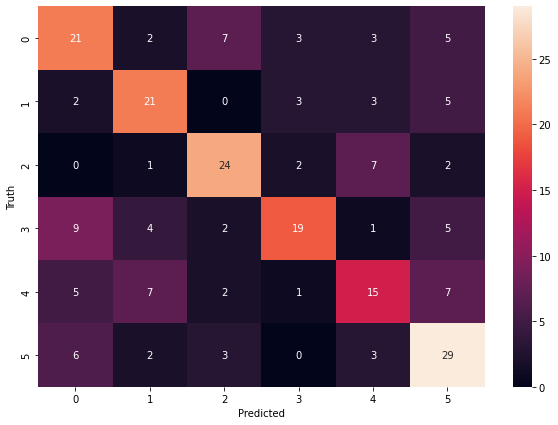

In [10]:
cm = confusion_matrix(y_test, np.argmax(model.predict(x_test), axis=1))
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

# Saving the Model #
To be loaded into the main program.

In [172]:
model.save('model_audio.keras')

# Extra Test Case #
To test the model on any audio clip, all we have to do is the below. We just have to set the path to the audio files, extract the features using the function defined earlier and then predict. 

Note that this program needs to take input from an audio file only (.wav). In order to precess the videos from our own dataset, we have a batch script using ffmpeg to split the mp4 audio into a wav file.

In [10]:
happy_pth = r"C:\Users\Keanu\Documents\Sound recordings\Happy.wav"
sad_pth = r"C:\Users\Keanu\Documents\Sound recordings\Sad.wav"
angry_pth = r"C:\Users\Keanu\Documents\Sound recordings\Angry.wav"

test_features = []

test_features.append(extract_features(happy_pth))
test_features.append(extract_features(sad_pth))
test_features.append(extract_features(angry_pth))

test_features = np.array(test_features)
test_features = np.expand_dims(test_features, axis=2)

In [173]:
np.argmax(model(test_features), axis=1)

array([0, 1, 4], dtype=int64)